In [1]:
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')

df

Loading dataset ...


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6QLFNz62dpOgQTloWuUbNh,All Things Must Pass,George Harrison,58,4I4xtHaIFOzhZfp1NIHkY6,All Things Must Pass (Remastered),1970-11-27,I didn’t know perm stood for permanent (wave),3e6gYPyrTbaB8BWgSHCt5j,rock,...,9,-8.278,1,0.0290,0.468000,0.001340,0.1110,0.441,122.676,226867
1,5JkKam7azyOKIW8Yy0u9fQ,Told You Once,Frank Brinelle,42,3wcloL3xLM9wKYrHG2K7y4,Told You Once,2018-05-13,Tropical Vibes,37i9dQZF1DX6RA5ZrA5a23,latin,...,8,-9.480,1,0.0942,0.062500,0.899000,0.0922,0.384,199.886,194437
2,0eOOTL9t2P448umBMf8vcS,Wasabi Terraces,Testiculo y Uno,56,5ryOyyt5nd8JUDtJreLgNv,Wasabi Terraces,2019-12-18,Jazz Vibes,37i9dQZF1DX0SM0LYsmbMT,rap,...,2,-11.114,1,0.0519,0.177000,0.609000,0.7060,0.583,87.213,188053
3,1yLFnEUfKDGCDeXcp1nIem,Magpakailanman,Rocksteddy,50,2Mng4RzoMnhpQcVo7TFkNy,Tsubtsatagilidakeyn,2005-05-11,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,rock,...,9,-6.988,1,0.0259,0.062100,0.000000,0.1570,0.332,105.042,326120
4,0zEnD8K1PZROX1Zsr7QZeq,Апокалипсис,Vitya AK,0,2qn8HTfrtqcGnrxKmGHa1R,Жирный,2012-06-01,RUSSIAN Gangster Rap,0Jw0HckkxCfIrOvpN081eV,rap,...,9,-6.502,0,0.3720,0.721000,0.000000,0.1120,0.708,169.980,259843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,40lcA4lHEMDvwoDMcwd1Xb,MoneyMoney,Tight Rhymes,41,1o9vkmWlF2YUoQuG0OosxB,MoneyMoney,2019-11-22,Great Pops,5SO7xYih5w8X5FEpKvU7Rt,latin,...,11,-5.118,1,0.3110,0.191000,0.052900,0.1100,0.569,86.037,187548
7936,0eaSdnDwPCoXMwPMwko4Ne,De Repente,Soraya,54,0mHG8x3lDk1RaGfHeNQGDV,Esenciales,2003-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,8,-11.527,1,0.0348,0.762000,0.002450,0.3370,0.805,118.033,247467
7937,2LyrufB6lwhwHq0mT3Dihs,No Dices Mas,Mœnia,2,1f34JO0Wtr9YFa4uXM27Vy,Grandes Exitos,2005-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,1,-6.292,1,0.0282,0.055500,0.000672,0.0735,0.690,127.032,255733
7938,7881kSmOadyJQqKw4J3InC,Tempo,Olszakumpel,56,2fDZUFbfio7feaIvhNIlTw,Tempo,2019-11-22,Generacja Hip Hop,37i9dQZF1DWXJnyndhASBe,rap,...,8,-3.846,1,0.2040,0.251000,0.000000,0.3030,0.566,149.923,205055


In [3]:
# exploratory analysis of the data frame

print("df lenght :")
print(len(df))
print("\ndf info :")
print(df.info())

print("\ncolumn dtypes:")
print(df.dtypes)
print("\nmissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # missing values are textual info, we can ignore as for the analysis we will consider only numerical features

df lenght :
7940

df info :
<class 'pandas.DataFrame'>
RangeIndex: 7940 entries, 0 to 7939
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  7940 non-null   str    
 1   track_name                7937 non-null   str    
 2   track_artist              7937 non-null   str    
 3   track_popularity          7940 non-null   int64  
 4   track_album_id            7940 non-null   str    
 5   track_album_name          7937 non-null   str    
 6   track_album_release_date  7940 non-null   str    
 7   playlist_name             7940 non-null   str    
 8   playlist_id               7940 non-null   str    
 9   playlist_genre            7940 non-null   str    
 10  playlist_subgenre         7940 non-null   str    
 11  danceability              7940 non-null   float64
 12  energy                    7940 non-null   float64
 13  key                       7940 non-null   int6

In [4]:
# playlist_genre and playlist_subgenre can be considered as our clustering label
print(df.playlist_genre.unique())
print(df.playlist_subgenre.unique())

<ArrowStringArray>
['rock', 'latin', 'rap', 'edm', 'r&b', 'pop']
Length: 6, dtype: str
<ArrowStringArray>
[           'permanent wave',                  'tropical',
                   'hip hop',              'classic rock',
              'gangster rap', 'progressive electro house',
            'new jack swing',             'latin hip hop',
                      'trap',                 'latin pop',
          'southern hip hop',                  'neo soul',
                'electropop',             'post-teen pop',
           'indie poptimism',                 'dance pop',
                 'hard rock',                   'pop edm',
                  'big room',                'album rock',
                 'reggaeton',                   'hip pop',
             'electro house',        'urban contemporary']
Length: 24, dtype: str


<Axes: xlabel='playlist_genre'>

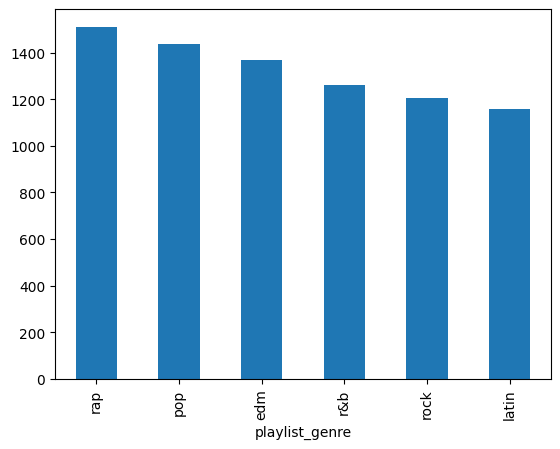

In [5]:
# plot labels distribution
df['playlist_genre'].value_counts().plot(kind='bar')

<Axes: xlabel='playlist_subgenre'>

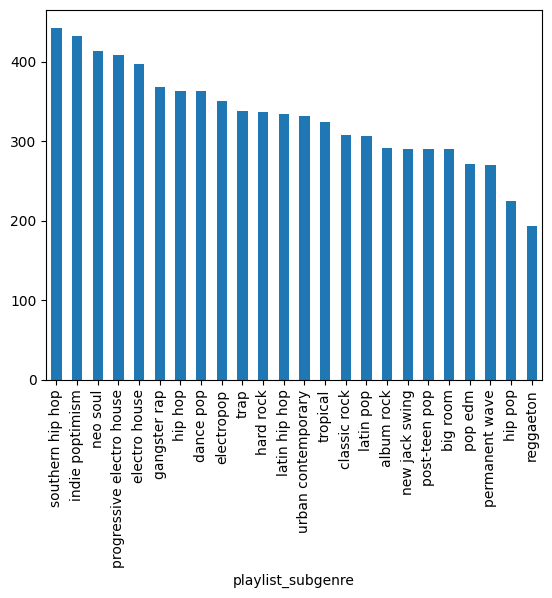

In [6]:
df['playlist_subgenre'].value_counts().plot(kind='bar')

In [7]:
# shuffle the data set
df = df.sample(frac=1).reset_index(drop=True)

# perform a train/test split
train_df, test_df = train_test_split(
    df, 
    test_size=0.28,                     # Takes 20% of the data
    stratify=df['playlist_subgenre'],   # Ensures 'label' proportions are kept
    random_state=17,                    # For reproducibility
)

In [8]:
train_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
4953,53G729jc38JTStNPNX4dF1,Nothing in Return,Monsune,52,3i7HKOoLl6nSPXaOjknDjN,Nothing in Return,2017-10-13,indie poptimism,1E5VdGGWkpDQ682gdvJAZH,pop,...,11,-5.747,0,0.0695,0.551,0.046000,0.1820,0.6850,100.004,232200
3164,0gH8MrEnV16R2YGzTHJpCZ,AMOR,Jonna Fraser,47,5otMiiTCoXNJlvOWnQNV2X,LION,2018-11-02,🔥🦁 GOOD VIBES ONLY 🦁🔥 // BROEDERLIEFDE || FREN...,1d0fonZHpN4LYHTKbmNRbm,latin,...,0,-6.797,1,0.0818,0.183,0.000000,0.0958,0.5530,89.971,183680
5978,7DP18u679fMurjsUxuxMHu,Rescue Me,DubVision,57,1lOgki2DNsUxFsalRq1wdj,Rescue Me,2019-06-14,"Festival Music 2019 - Warm Up Music (EDM, Big ...",73uj4YmsC7SJ6SbUMTvf07,edm,...,6,-4.610,0,0.0427,0.069,0.000368,0.0664,0.2350,128.007,187383
49,2cBNg1EvaRCTSl8xHeYJCy,Se Faltar Estrelas,Luigi e Leandro,17,0VaxN98rAElRAWvVuBRB6X,Se Faltar Estrelas,2019-12-27,Tropical Rising,37i9dQZF1DX07X8UDWKEwP,latin,...,2,-3.562,1,0.0289,0.285,0.000000,0.2810,0.6390,127.963,166620
7745,4qetR2UUyBeUrJ9DbYrpVQ,Stop It,FISHER,70,3fLyVygsOa9KL5OqdiX8Va,Oi Oi,2017-11-10,💊ELECTRO-HOUSE-TECH💊,0AFYmoSuoMQiGGjzvBwr6u,edm,...,8,-7.207,1,0.0518,0.024,0.657000,0.2050,0.8700,124.016,163790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7585,6C9wrNf3MBFoy7tihOMeWI,Accidente,Making Movies,27,0nZJ2vifwaMfiyAwfvIh1Q,Accidente,2019-11-15,Paraíso Tropical,2v41efarffe6iY8qpMK5Gj,latin,...,6,-7.958,1,0.0466,0.498,0.008570,0.2060,0.7880,130.821,265440
6322,4L2K7JKseFCBoHMZEAszW0,Jealous,Labrinth,79,2JgVVnno2fzdmV1BqwdQBi,Jealous,2014-11-21,Urban contemporary,1ZlL3IQS8eB0s0RMxz02yD,r&b,...,1,-8.948,1,0.0460,0.873,0.000000,0.1070,0.0935,128.532,287693
5436,5rxKLWFvozGCBDG7angcBe,Groove Me,Guy,0,48WHFlK379Bh4ifuYpHA4T,The Very Best Of Guy,2002-01-01,New Jack Swing,4nX6BscFtR1CozSCfv2cuR,r&b,...,1,-6.334,1,0.1070,0.063,0.000000,0.5140,0.7640,107.956,274135
4593,5CXmbqFE0mRXOYXgEze8q3,Strangers,Vigiland,61,6SUYNqVAlo0QE0q8pTJdvA,Strangers,2019-01-25,Fresh EDM | Progressive House | Electro House ...,0FCHg9zJMNNiOokh3hVcxd,edm,...,11,-4.960,1,0.0782,0.195,0.000000,0.4220,0.5340,124.209,167706


In [9]:
# select only numerical features and remove the labels

df_features = train_df[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
    
df_features

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
4953,0.672,0.739,11,-5.747,0,0.0695,0.551,0.046000,0.1820,0.6850,100.004,232200
3164,0.824,0.712,0,-6.797,1,0.0818,0.183,0.000000,0.0958,0.5530,89.971,183680
5978,0.494,0.739,6,-4.610,0,0.0427,0.069,0.000368,0.0664,0.2350,128.007,187383
49,0.762,0.775,2,-3.562,1,0.0289,0.285,0.000000,0.2810,0.6390,127.963,166620
7745,0.860,0.824,8,-7.207,1,0.0518,0.024,0.657000,0.2050,0.8700,124.016,163790
...,...,...,...,...,...,...,...,...,...,...,...,...
7585,0.591,0.687,6,-7.958,1,0.0466,0.498,0.008570,0.2060,0.7880,130.821,265440
6322,0.435,0.155,1,-8.948,1,0.0460,0.873,0.000000,0.1070,0.0935,128.532,287693
5436,0.808,0.869,1,-6.334,1,0.1070,0.063,0.000000,0.5140,0.7640,107.956,274135
4593,0.718,0.594,11,-4.960,1,0.0782,0.195,0.000000,0.4220,0.5340,124.209,167706


In [10]:
# perform standardization over the numerical features of the dataset
scaler = StandardScaler()
X = scaler.fit_transform(df_features)

In [11]:
# PCA for 2-D visualisation
pca = PCA(n_components=2, random_state=17)
X_2d = pca.fit_transform(X)
print(f"PCA explained variance (2 components): "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA explained variance (2 components): 31.4%


In [12]:
def cluster_metrics(X, labels):
    # Return silhouette, and CH scores (skip if < 2 clusters)
    unique = set(labels)
    if len(unique) < 2:
        return {"model": name,
                "silhouette": np.nan,
                "davies_bouldin" : np.nan,
                "calinski_harabasz": np.nan,
                "n_clusters": len(unique)}
    
    sil  = silhouette_score(X, labels)          # the higher the better
    db   = davies_bouldin_score(X, labels)      # Variance Ratio Criterion (the lower the better)
    ch   = calinski_harabasz_score(X, labels)   # the higher the better
    return {"silhouette" : round(sil, 4),       
            "calinski_harabasz" : round(ch, 2), 
            "davies_bouldin" : round(db, 4),    
            "n_clusters" : len(unique)}

In [14]:
# K-MEANS — HYPERPARAMETER k = 2..10

K_RANGE = range(2, 11)
km_inertias, km_sil, km_db, km_ch = [], [], [], []
km_labels_all = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=17)
    lbl = km.fit_predict(X)
    km_labels_all[k] = lbl
    km_inertias.append(km.inertia_)
    m = cluster_metrics(X, lbl)
    km_sil.append(m["silhouette"])
    km_ch.append(m["calinski_harabasz"])
    km_db.append(m["davies_bouldin"])
    print(f"k={k:2d} | Inertia={km.inertia_:.4f} | Silhouette={m['silhouette']:.4f} | CH={m['calinski_harabasz']:.4f} | DB={m['davies_bouldin']:.4f}")

k= 2 | Inertia=60717.1340 | Silhouette=0.1377 | CH=741.1000 | DB=2.5206
k= 3 | Inertia=55874.7029 | Silhouette=0.1016 | CH=650.1500 | DB=2.5137
k= 4 | Inertia=52093.2186 | Silhouette=0.1059 | CH=603.0300 | DB=2.2827
k= 5 | Inertia=48974.7330 | Silhouette=0.1035 | CH=571.9000 | DB=2.1749
k= 6 | Inertia=46450.2368 | Silhouette=0.0999 | CH=544.3700 | DB=2.0434
k= 7 | Inertia=44379.2285 | Silhouette=0.1038 | CH=519.1300 | DB=1.9558
k= 8 | Inertia=42996.7777 | Silhouette=0.0957 | CH=485.4100 | DB=1.9781
k= 9 | Inertia=41760.8150 | Silhouette=0.0991 | CH=458.3400 | DB=1.9542
k=10 | Inertia=40436.0117 | Silhouette=0.0984 | CH=441.4600 | DB=1.9006


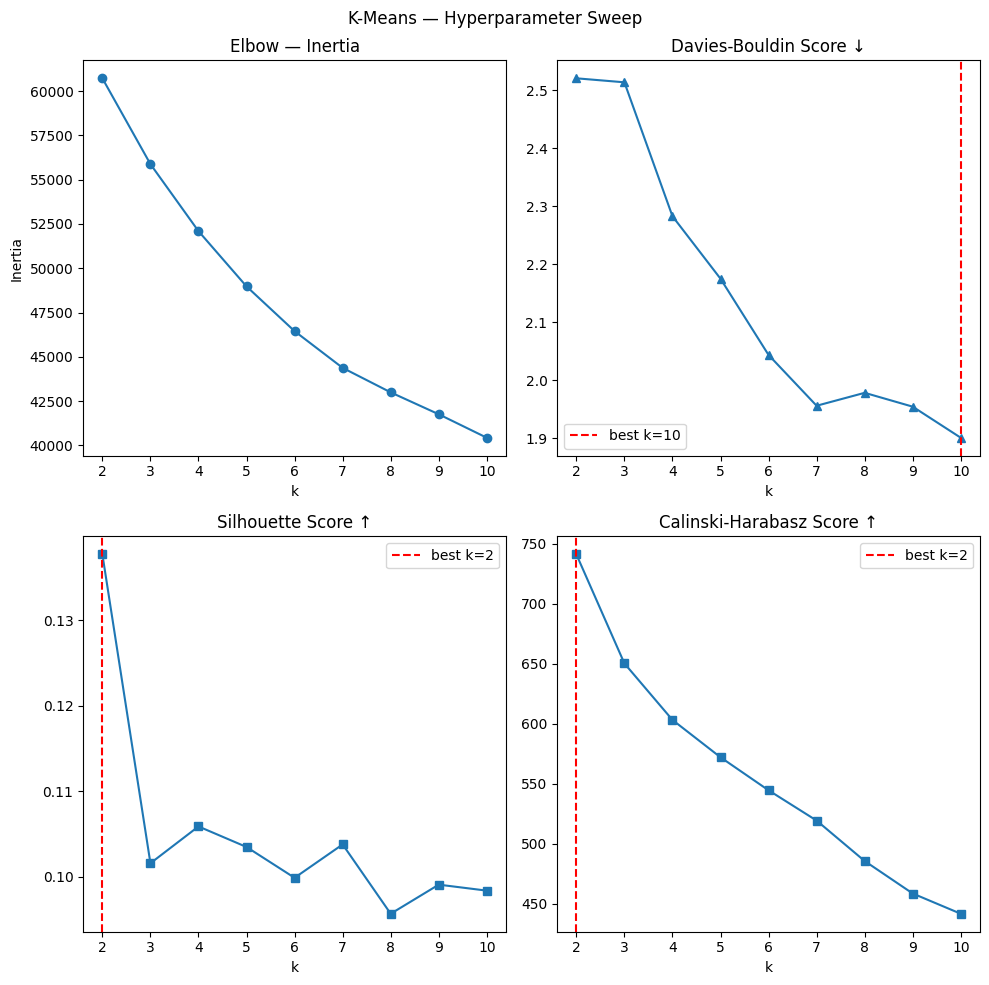

In [ ]:
# Plot K-Means diagnostics
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("K-Means — Hyperparameter Sweep")

axes[0][0].plot(list(K_RANGE), km_inertias, "o-",)
axes[0][0].set_title("Elbow — Inertia")
axes[0][0].set_xlabel("k")
axes[0][0].set_ylabel("Inertia")

best_k_db = K_RANGE.start + int(np.argmin(km_db))
axes[0][1].plot(list(K_RANGE), km_db, "^-")
axes[0][1].axvline(best_k_db, color="red", linestyle="--", label=f"best k={best_k_db}")
axes[0][1].set_title("Davies-Bouldin Score ↓")
axes[0][1].set_xlabel("k")
axes[0][1].legend()

best_k_s = K_RANGE.start + int(np.argmax(km_sil))
axes[1][0].plot(list(K_RANGE), km_sil, "s-")
axes[1][0].axvline(best_k_s, color="red", linestyle="--", label=f"best k={best_k_s}")
axes[1][0].set_title("Silhouette Score ↑")
axes[1][0].set_xlabel("k")
axes[1][0].legend()

best_k_ch = K_RANGE.start + int(np.argmax(km_ch))
axes[1][1].plot(list(K_RANGE), km_ch, "s-")
axes[1][1].axvline(best_k_ch, color="red", linestyle="--", label=f"best k={best_k_ch}")
axes[1][1].set_title("Calinski-Harabasz Score ↑")
axes[1][1].set_xlabel("k")
axes[1][1].legend()

plt.tight_layout()
plt.show()

# 7 is a good tradeoff among all metrics
# be aware that for some metrics the elbow method can be applied while for others not (ones for which the highest the better)

In [ ]:
# in this dictionary we have all the labels for all different k values, it can be used down for plotting
km_labels_all

{2: array([0, 1, 1, ..., 1, 1, 1], shape=(5716,), dtype=int32),
 3: array([2, 2, 0, ..., 2, 2, 0], shape=(5716,), dtype=int32),
 4: array([2, 2, 0, ..., 2, 2, 0], shape=(5716,), dtype=int32),
 5: array([3, 3, 0, ..., 3, 3, 0], shape=(5716,), dtype=int32),
 6: array([5, 2, 1, ..., 2, 2, 2], shape=(5716,), dtype=int32),
 7: array([2, 3, 1, ..., 4, 3, 3], shape=(5716,), dtype=int32),
 8: array([3, 4, 6, ..., 7, 4, 4], shape=(5716,), dtype=int32),
 9: array([3, 4, 2, ..., 6, 4, 4], shape=(5716,), dtype=int32),
 10: array([2, 8, 1, ..., 5, 4, 4], shape=(5716,), dtype=int32)}

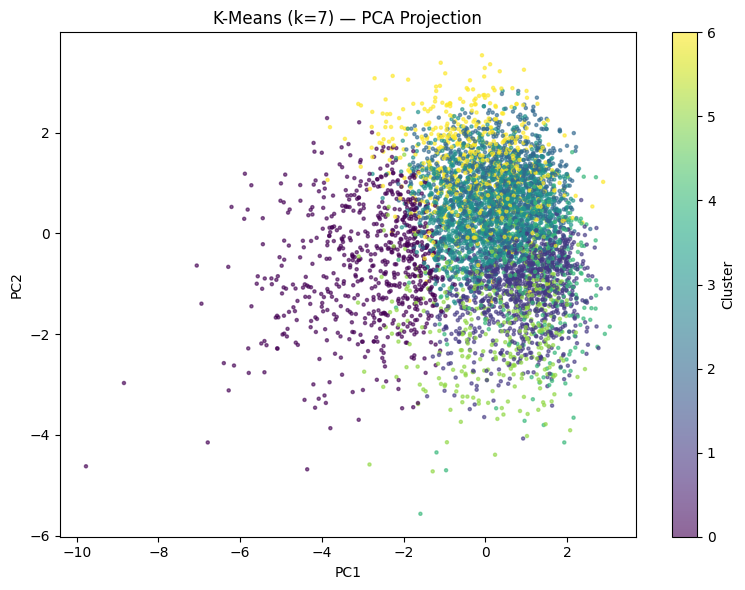

In [27]:
target_k = 7

# Plot best K-Means clusters (PCA 2-D)
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=km_labels_all[target_k],
                     s=5, alpha=0.6)
ax.set_title(f"K-Means (k={target_k}) — PCA Projection")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()